# Fake News Detection

In [20]:
"""
1 Importing libraries
"""

# Libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Libraries for graphic visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Text Processing Libraries (NLP)
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# To save the model in Pickle format
import pickle
from google.colab import files

print("Libraries successfully loaded!")

Libraries successfully loaded!


In [21]:
"""
2 Dataset loading and inspection
"""
true_news = "https://media.githubusercontent.com/media/Alessio8-ai/Project-files/refs/heads/main/True_news.csv"
fake_news = "https://media.githubusercontent.com/media/Alessio8-ai/Project-files/refs/heads/main/Fake_news.csv"


# We load data into a DataFrame
df_true = pd.read_csv(true_news)
df_fake = pd.read_csv(fake_news)

print("--- TRUE NEWS STATISTICS ---")
print(f"Dataset size: {df_true.shape[0]} rows and {df_true.shape[1]} columns")
print("\nColumns and data types:")
print(df_true.dtypes)
print("\nFirst 3 rows of example:")
print(df_true.head(3))

print("\n" + "="*50 + "\n")

print("--- FAKE NEWS STATISTICS ---")
print(f"Dataset size: {df_fake.shape[0]} rows and {df_fake.shape[1]} columns")
print("\nColumns and data types:")
print(df_fake.dtypes)
print("\nFirst 3 rows of example:")
print(df_fake.head(3))

--- TRUE NEWS STATISTICS ---
Dataset size: 21417 rows and 4 columns

Columns and data types:
title      object
text       object
subject    object
date       object
dtype: object

First 3 rows of example:
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   


--- FAKE NEWS STATISTICS ---
Dataset size: 23481 rows and 4 columns

Columns and data types:
title      object
text       object
subject    object
date       object
dtype: object

First 3 row

In [22]:
"""
3 CREATE 'TARGET' COLUMN AND JOIN DATASETS
"""

# Let's add the target column: 1 for true news, 0 for fake news
df_true["target"] = 1
df_fake["target"] = 0

# Let's merge the two datasets one under the other
df = pd.concat([df_true, df_fake], ignore_index=True)

print(f"Size of the merged dataset: {df.shape[0]} rows and {df.shape[1]} columns")

# Checking for missing values (Null/NaN)
print("\n--- Missing values ​​per column ---")
print(df.isnull().sum())

# Check and remove duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates successfully removed!")
    print(f"New dataset dimensions: {df.shape[0]} rows")

# Let's see how many true and false news we have after the cleanup
print("\n--- Class distribution (0 = Fake, 1 = Real) ---")
print(df['target'].value_counts())

Size of the merged dataset: 44898 rows and 5 columns

--- Missing values ​​per column ---
title      0
text       0
subject    0
date       0
target     0
dtype: int64

Number of duplicate rows found: 209
Duplicates successfully removed!
New dataset dimensions: 44689 rows

--- Class distribution (0 = Fake, 1 = Real) ---
target
0    23478
1    21211
Name: count, dtype: int64


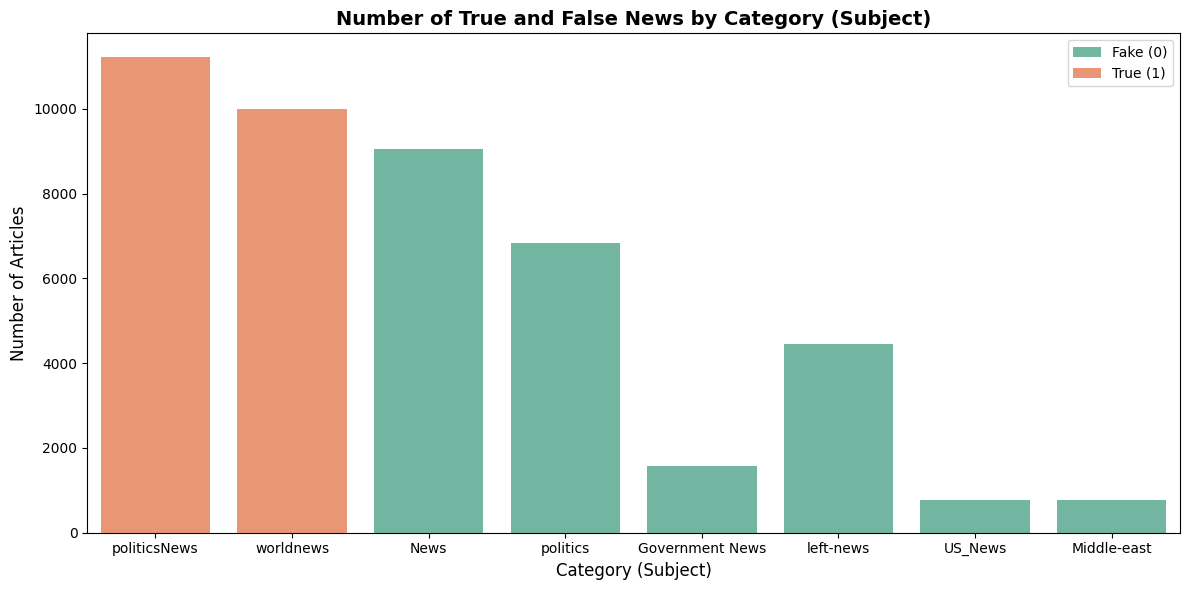

In [23]:
"""
4 NEWS DISTRIBUTION BY CATEGORY
"""

plt.figure(figsize=(12, 6))

# Let's create a bar chart that counts the news, divided by target (0=Fake, 1=True)
sns.countplot(data=df, x="subject", hue="target", palette="Set2")

plt.title("Number of True and False News by Category (Subject)", fontsize=14, fontweight="bold")
plt.xlabel("Category (Subject)", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.legend(["Fake (0)", "True (1)"])
plt.tight_layout()
plt.show()

### Are fake news titles written differently?
### They often use multiple words or characters to grab attention (clickbait). Let's check this by calculating the text length.

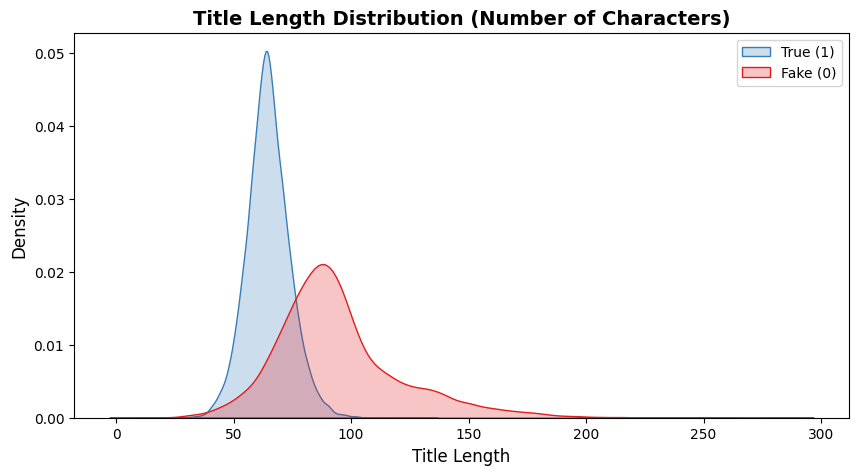

Average length of titles:
target
0    94.194054
1    64.658291
Name: title_length, dtype: float64


In [24]:
"""
5 ANALYSIS OF THE LENGTH OF THE TITLES
"""

# Let's calculate the number of characters in each title
df["title_length"] = df["title"].apply(len)

plt.figure(figsize=(10, 5))

# Let's create a density plot (KDE) to compare the lengths
sns.kdeplot(data=df, x="title_length", hue="target", fill=True, palette="Set1", common_norm=False)

plt.title("Title Length Distribution (Number of Characters)", fontsize=14, fontweight="bold")
plt.xlabel("Title Length", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(["True (1)", "Fake (0)"])
plt.show()

# Let's also look at the numerical average
print("Average length of titles:")
print(df.groupby("target")["title_length"].mean())

In [25]:
"""
6 PREPROCESSING NLP: DEFINITION OF THE CLEANING FUNCTION
"""

# Let's download the resources needed for NLTK (Stopwords and Lemmatization Dictionary)
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Initialize the Lemmatizer and the English stopword list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    # Let's convert everything to lowercase
    text = text.lower()

    # Remove the text in square brackets
    text = re.sub(r"\[.*?\]", "", text)

    # Let's remove punctuation and numbers
    text = re.sub(r"[%s]" % re.escape(string.punctuation), "", text)
    text = re.sub(r"\w*\d\w*", "", text)

    # Tokenization and Removal of Stopwords
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]

    # Lemmatization (es. "studies" -> "study")
    lemmatized_words = [lemmatizer.lemmatize(word) for word in cleaned_words]

    # Reassembles words into a single clean string
    return " ".join(lemmatized_words)

print("Function 'clean_text' defined and ready to use!")

Function 'clean_text' defined and ready to use!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [26]:
# Let's combine the title and text into a single column separated by a space
df["full_text"] = df["title"] + " " + df["text"]

# Let's apply the cleaning function
print("Start cleaning the text.")
df["cleaned_text"] = df["full_text"].apply(clean_text)
print("Cleaning completed!")

# Let's see the result on an example line
print("\n--- ORIGINAL TEXT ---")
print(df["full_text"].iloc[0][:200] + "...")
print("\n--- CLEAN TEXT ---")
print(df["cleaned_text"].iloc[0][:200] + "...")

Start cleaning the text.
Cleaning completed!

--- ORIGINAL TEXT ---
As U.S. budget fight looms, Republicans flip their fiscal script WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of...

--- CLEAN TEXT ---
u budget fight loom republican flip fiscal script washington reuters head conservative republican faction u congress voted month huge expansion national debt pay tax cut called “fiscal conservative” s...


In [27]:
"""
7 DATA DIVISION, VECTORIZATION (TF-IDF) AND MODEL TRAINING
"""

# Separation into Feature (X) and Target (y)
X = df["cleaned_text"]
y = df["target"]

# Division into Training Set (80%) and Test Set (20%)
# We use random_state=42 to make sure that the division is always identical if you rerun the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape[0]} articles")
print(f"Test Data: {X_test.shape[0]} articles\n")

# Vectorization with TF-IDF
tfidf = TfidfVectorizer(max_features=5000) # Select the 5000 most important words

# We learn the vocabulary and transform the training data
X_train_tfidf = tfidf.fit_transform(X_train)
# Let's transform the test data
X_test_tfidf = tfidf.transform(X_test)

print("Vectorization completed successfully!")
print(f"Training matrix: {X_train_tfidf.shape} (Rows, Keywords)\n")

# Initializing Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=42)
}

# Model Training
trained_models = {}
for name, model in models.items():
    print(f"Model training {name}...")
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model

print("\nAll models have been trained successfully!")

Training Data: 35751 articles
Test Data: 8938 articles

Vectorization completed successfully!
Training matrix: (35751, 5000) (Rows, Keywords)

Model training Logistic Regression...
Model training Multinomial Naive Bayes...
Model training Linear SVM...

All models have been trained successfully!


In [28]:
"""
8 FINAL EVALUATION AND COMPARISON OF THE MODELS
"""

results = []

# We iterate over the trained models to calculate the metrics
for name, model in trained_models.items():
    # We make predictions on the hidden test set
    y_pred = model.predict(X_test_tfidf)

    # Let's calculate the main metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # We save the results in a list
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    # We show the textual classification report
    print(f"=== REPORT FOR THE MODEL: {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Vero (1)']))
    print("-" * 50)

# Let's create a DataFrame to compare them in a table
df_comparison = pd.DataFrame(results)
print("\nFINAL COMPARATIVE TABLE:")
print(df_comparison.to_string(index=False))
print("=" * 50)

print("\nTHE MOST EFFECTIVE MODEL WE ARE GOING TO EXPORT IS THE LINEAR SVM")

=== REPORT FOR THE MODEL: Logistic Regression ===
              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99      4696
    Vero (1)       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938

--------------------------------------------------
=== REPORT FOR THE MODEL: Multinomial Naive Bayes ===
              precision    recall  f1-score   support

    Fake (0)       0.94      0.93      0.94      4696
    Vero (1)       0.93      0.93      0.93      4242

    accuracy                           0.93      8938
   macro avg       0.93      0.93      0.93      8938
weighted avg       0.93      0.93      0.93      8938

--------------------------------------------------
=== REPORT FOR THE MODEL: Linear SVM ===
              precision    recall  f1-score   support

    Fake (0)       1.00      0.99      0.99 

In [29]:
"""
9 SAVING THE MODEL AND VECTORIZER (PICKLE)
"""

# We select the winning model
winning_model = trained_models["Linear SVM"]

# We save the model in pickle format
with open('fake_news_svm_model.pkl', 'wb') as model_file:
    pickle.dump(winning_model, model_file)

# We save the TF-IDF vectorizer in pickle format
with open('tfidf_vectorizer.pkl', 'wb') as vocab_file:
    pickle.dump(tfidf, vocab_file)

print("Pickle files generated successfully!")


Pickle files generated successfully!
